# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# K-Means Clustering: Old Faithful Geyser Segmentation

Segment eruptions of the Old Faithful geyser (Yellowstone National Park, WY, USA)
using `waiting` time between eruptions and `eruptions` duration.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

plt.rcParams['figure.figsize'] = (7, 5)


In [2]:
# Load the classic "Old Faithful" dataset (272 eruptions).
# Columns: eruptions (duration in minutes), waiting (time to next eruption in minutes)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"

try:
    df = pd.read_csv(url)
    # seaborn's geyser.csv uses columns: duration, waiting, kind -> rename to match assignment
    df = df.rename(columns={"duration": "eruptions"})[["eruptions", "waiting"]]
    print("Loaded dataset from GitHub, shape:", df.shape)
except Exception as e:
    print("Download failed, using bundled fallback data instead:", e)
    data = {
        "eruptions": [3.6,1.8,3.333,2.283,4.533,2.883,4.7,3.6,1.95,4.35,
                      1.833,3.917,4.2,1.75,4.7,2.167,1.75,4.8,1.6,4.25],
        "waiting":  [79,54,74,62,85,55,88,85,51,85,
                     54,84,78,47,83,52,62,84,52,79]
    }
    df = pd.DataFrame(data)

df.head()


Loaded dataset from GitHub, shape: (272, 2)


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


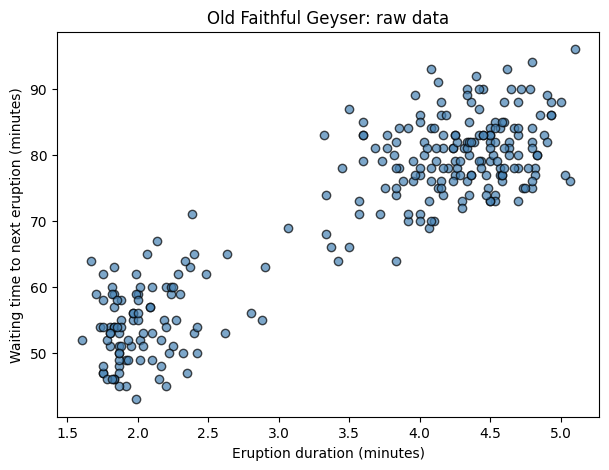

In [3]:
# Quick look at the raw distribution before clustering
plt.scatter(df["eruptions"], df["waiting"], c="steelblue", edgecolor="k", alpha=0.7)
plt.xlabel("Eruption duration (minutes)")
plt.ylabel("Waiting time to next eruption (minutes)")
plt.title("Old Faithful Geyser: raw data")
plt.show()


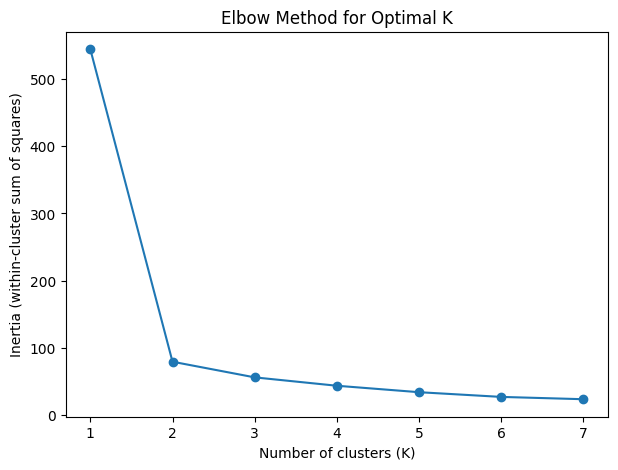

In [4]:
# Scale features so both dimensions contribute equally to distance calculations
X = df[["eruptions", "waiting"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to pick K
inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, "o-")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal K")
plt.show()


In [5]:
# The elbow typically appears around K=2 for this dataset (short/cool vs long/hot eruptions)
K_OPTIMAL = 2

kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster centers (eruption duration, waiting time):")
for i, c in enumerate(centers_original):
    print(f"  Cluster {i}: eruptions={c[0]:.2f} min, waiting={c[1]:.2f} min")


Cluster centers (eruption duration, waiting time):
  Cluster 0: eruptions=4.30 min, waiting=80.08 min
  Cluster 1: eruptions=2.05 min, waiting=54.59 min


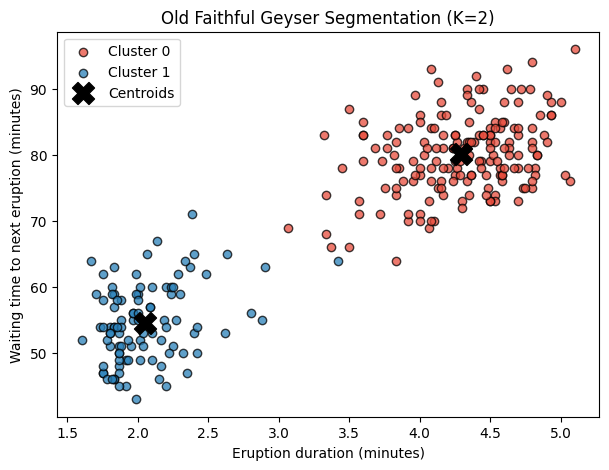

In [6]:
colors = ["#e74c3c", "#2980b9", "#27ae60", "#f39c12"]

plt.figure(figsize=(7,5))
for c in range(K_OPTIMAL):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["eruptions"], subset["waiting"],
                c=colors[c], label=f"Cluster {c}", edgecolor="k", alpha=0.75)

plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c="black", marker="X", s=250, label="Centroids")

plt.xlabel("Eruption duration (minutes)")
plt.ylabel("Waiting time to next eruption (minutes)")
plt.title(f"Old Faithful Geyser Segmentation (K={K_OPTIMAL})")
plt.legend()
plt.show()
